In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Section 1 — Timeseries Review

In [4]:
# MAIN
from utils import (load_q_diepoldsau, load_q_gisingen,
                   load_ssc_diepoldsau, load_ssc_gisingen,
                   compute_monthly_mean, detrend_series, remove_seasonality, find_nan_gaps)

# Load and resample to monthly means
q_diep   = compute_monthly_mean(load_q_diepoldsau())["Q"]
q_gis    = compute_monthly_mean(load_q_gisingen())["Q"]
ssc_diep = compute_monthly_mean(load_ssc_diepoldsau())["SSC"]
ssc_gis  = compute_monthly_mean(load_ssc_gisingen())["SSC"]

# Q — detrend then monthly standardisation
q_diep_dt, t_q_diep = detrend_series(q_diep)
q_gis_dt,  t_q_gis  = detrend_series(q_gis)

q_diep_sa, sm_q_diep, ss_q_diep = remove_seasonality(q_diep_dt)
q_gis_sa,  sm_q_gis,  ss_q_gis  = remove_seasonality(q_gis_dt)

# SSC — log-transform before detrending and monthly standardisation.
# SSC seasonality is multiplicative: summer peaks are proportionally larger,
# not just additively larger.  Log-transform converts this to an additive
# structure so that monthly standardisation removes it cleanly and the
# residuals are closer to Gaussian (log-normal is the standard distribution
# for sediment concentration data).
log_ssc_diep = np.log(ssc_diep)
log_ssc_gis  = np.log(ssc_gis)

log_ssc_diep_dt, t_log_ssc_diep = detrend_series(log_ssc_diep)
log_ssc_gis_dt,  t_log_ssc_gis  = detrend_series(log_ssc_gis)

log_ssc_diep_sa, sm_log_ssc_diep, ss_log_ssc_diep = remove_seasonality(log_ssc_diep_dt)
log_ssc_gis_sa,  sm_log_ssc_gis,  ss_log_ssc_gis  = remove_seasonality(log_ssc_gis_dt)

# ── Find consecutive NaN gaps in SSC series and split for separate analysis ────
# Identify continuous periods of missing values in raw SSC data
# Split at the largest gap to enable before/after segment analysis

gaps_diep = find_nan_gaps(ssc_diep)
gaps_gis = find_nan_gaps(ssc_gis)

# Split Diepoldsau at largest gap
if gaps_diep:
    largest_gap_diep = max(gaps_diep, key=lambda x: x['length'])
    gap_before_diep = largest_gap_diep['end_date']
    gap_after_diep = ssc_diep.index[largest_gap_diep['end_idx'] + 1]
    before_gap_diep = ssc_diep.loc[:gap_before_diep].dropna()
    after_gap_diep = ssc_diep.loc[gap_after_diep:].dropna()
else:
    before_gap_diep = ssc_diep.dropna()
    after_gap_diep = pd.Series([], dtype=float)

# Split Gisingen at largest gap
if gaps_gis:
    largest_gap_gis = max(gaps_gis, key=lambda x: x['length'])
    gap_before_gis = largest_gap_gis['end_date']
    gap_after_gis = ssc_gis.index[largest_gap_gis['end_idx'] + 1]
    before_gap_gis = ssc_gis.loc[:gap_before_gis].dropna()
    after_gap_gis = ssc_gis.loc[gap_after_gis:].dropna()
else:
    before_gap_gis = ssc_gis.dropna()
    after_gap_gis = pd.Series([], dtype=float)

# Apply log-transform and processing to split segments
log_before_gap_diep = np.log(before_gap_diep)
log_after_gap_diep = np.log(after_gap_diep)
log_before_gap_gis = np.log(before_gap_gis)
log_after_gap_gis = np.log(after_gap_gis)

# Detrend and remove seasonality from split segments
log_before_gap_diep_dt, _ = detrend_series(log_before_gap_diep)
log_after_gap_diep_dt, _ = detrend_series(log_after_gap_diep)
log_before_gap_gis_dt, _ = detrend_series(log_before_gap_gis)
log_after_gap_gis_dt, _ = detrend_series(log_after_gap_gis)

before_gap_diep_sa, _, _ = remove_seasonality(log_before_gap_diep_dt)
after_gap_diep_sa, _, _ = remove_seasonality(log_after_gap_diep_dt)
before_gap_gis_sa, _, _ = remove_seasonality(log_before_gap_gis_dt)
after_gap_gis_sa, _, _ = remove_seasonality(log_after_gap_gis_dt)

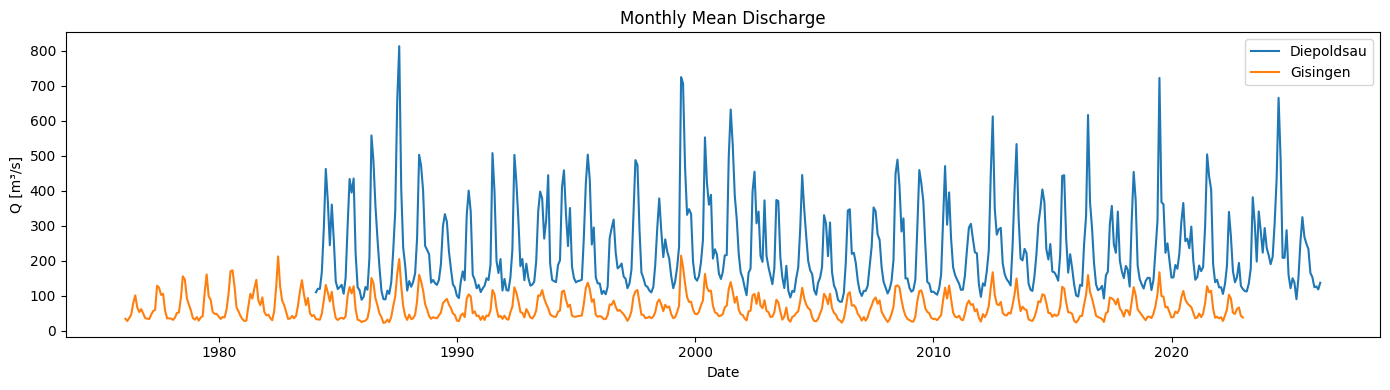

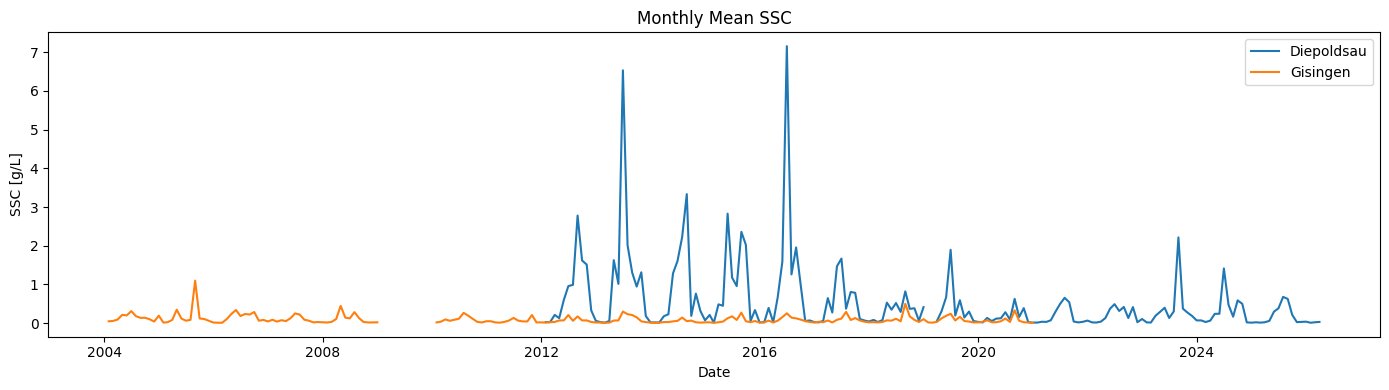

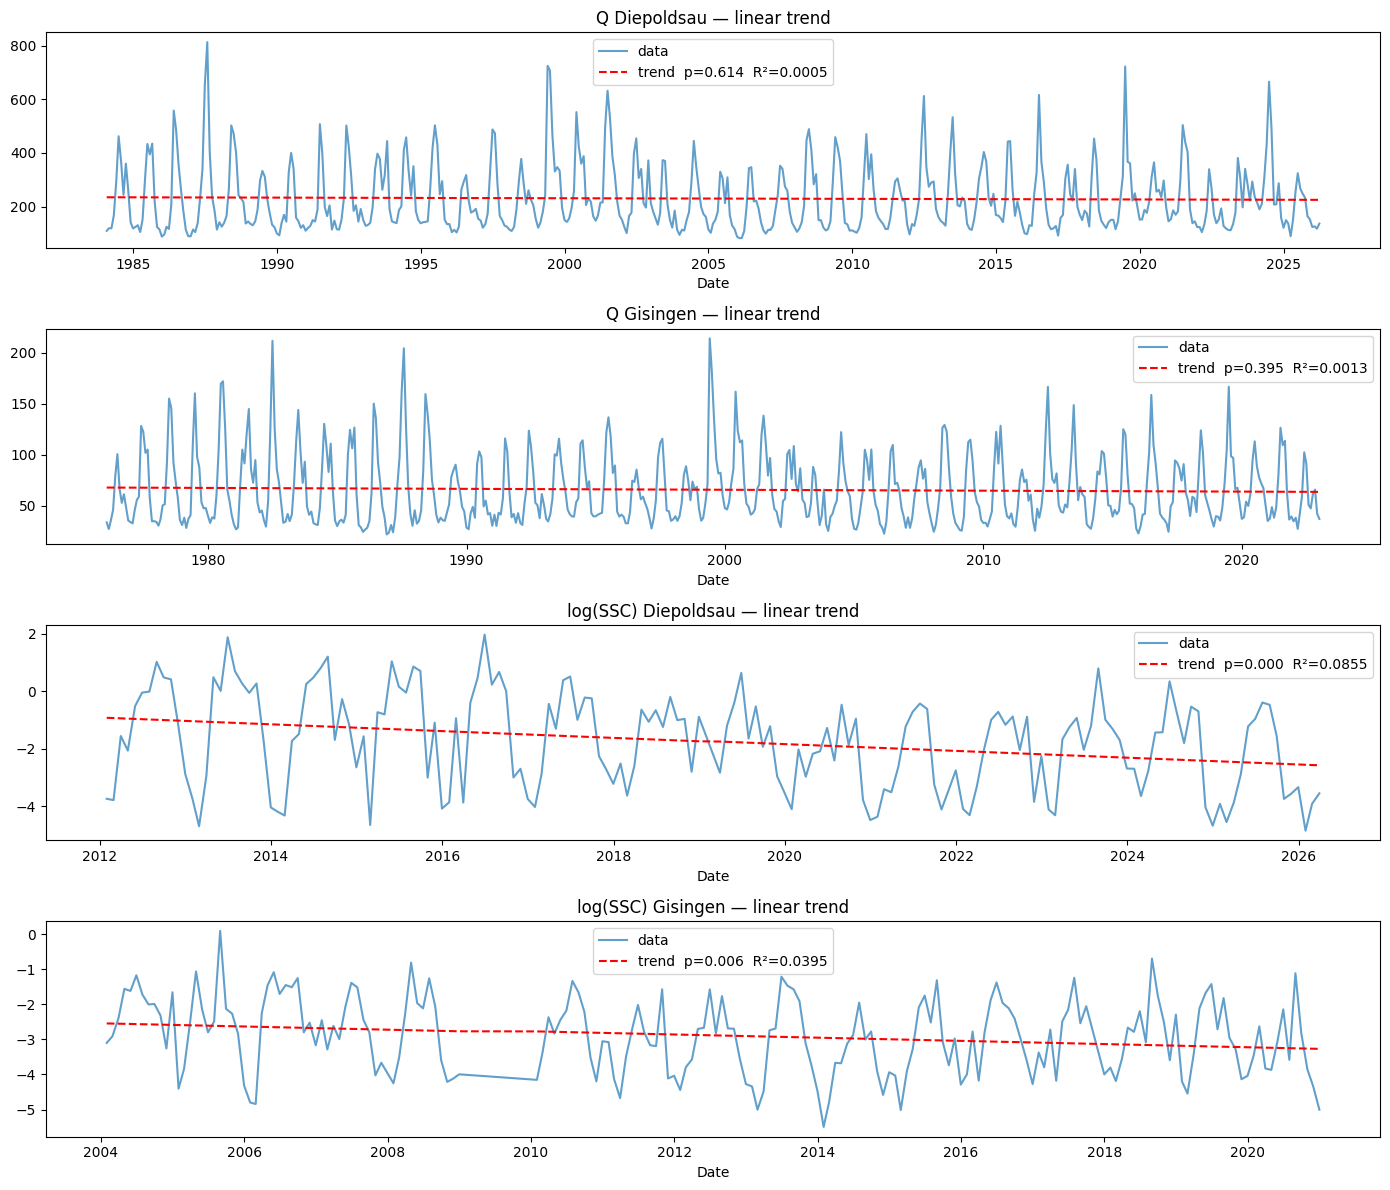

In [5]:
# PLOT
from utils import plot_timeseries, plot_trend_fit

plot_timeseries({"Diepoldsau": q_diep, "Gisingen": q_gis},
                ylabel="Q [m³/s]", title="Monthly Mean Discharge")
plot_timeseries({"Diepoldsau": ssc_diep, "Gisingen": ssc_gis},
                ylabel="SSC [g/L]", title="Monthly Mean SSC")

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
plot_trend_fit(q_diep,       t_q_diep,       title="Q Diepoldsau — linear trend",        ax=axes[0])
plot_trend_fit(q_gis,        t_q_gis,        title="Q Gisingen — linear trend",          ax=axes[1])
plot_trend_fit(log_ssc_diep, t_log_ssc_diep, title="log(SSC) Diepoldsau — linear trend", ax=axes[2])
plot_trend_fit(log_ssc_gis,  t_log_ssc_gis,  title="log(SSC) Gisingen — linear trend",   ax=axes[3])
plt.tight_layout()
plt.show()

In [6]:
# PRINT
rows = [
    ("Q Diepoldsau",        t_q_diep),
    ("Q Gisingen",          t_q_gis),
    ("log(SSC) Diepoldsau", t_log_ssc_diep),
    ("log(SSC) Gisingen",   t_log_ssc_gis),
]
df_trend = pd.DataFrame([{
    "Series":            name,
    "Slope (per month)": f"{t['slope']:.4e}",
    "p-value":           f"{t['p_value']:.4f}",
    "R²":                f"{t['r_squared']:.4f}",
    "Significant (5%)":  t['significant'],
    "Detrending":        "trend subtracted" if t['significant'] else "mean subtracted"
} for name, t in rows])
print(df_trend.to_string(index=False))

             Series Slope (per month) p-value     R²  Significant (5%)       Detrending
       Q Diepoldsau       -1.9002e-02  0.6136 0.0005             False  mean subtracted
         Q Gisingen       -7.5179e-03  0.3952 0.0013             False  mean subtracted
log(SSC) Diepoldsau       -9.8338e-03  0.0001 0.0855              True trend subtracted
  log(SSC) Gisingen       -3.7916e-03  0.0057 0.0395              True trend subtracted


**Comments — Section 1: Detrending for Stationarity**

Neither discharge series shows a statistically significant trend (Q Diepoldsau: p = 0.61, Q Gisingen: p = 0.40), so only the mean was subtracted. Both Q series can be considered **stationary in mean** over their observation period, suggesting no long-term change in the flow regime at either station. This is a fundamental prerequisite for AR/ARMA modelling.

Both log(SSC) series show statistically significant negative trends (log(SSC) Diepoldsau: p = 0.0001, R² = 0.086; log(SSC) Gisingen: p = 0.006, R² = 0.040), so the linear trend was subtracted. Suspended sediment concentrations have been declining over time at both stations — a well-documented pattern in Alpine catchments due to river channelisation, bank protection, and upstream reservoir trapping. **Removing this trend is essential:** without detrending, the series would be non-stationary, making AR/ARMA coefficients unstable and order selection unreliable.

The log-transform is applied to SSC before detrending because SSC seasonality is **multiplicative** — summer peaks are proportionally larger, not just additively larger. Log-transform converts this to an additive structure so that monthly standardisation removes it cleanly, and the residuals are closer to Gaussian (log-normal is the standard distribution for sediment concentration data).

After detrending, **monthly standardisation** is applied (Thomas-Fiering approach: subtract monthly mean, divide by monthly std). Alpine rivers exhibit a strong annual cycle driven by snowmelt and glacier runoff. Without seasonal removal, this deterministic cycle dominates the autocorrelation function — the ACF shows a large spike at lag 12 and AIC-based order selection picks a high AR order, with model parameters dedicated to tracking seasonality rather than short-range persistence. After seasonal removal, residuals are described with AR(1–3) or ARMA(2–4), yielding a far more **parsimonious** model that captures only the stochastic dynamics.

**Summary of preprocessing chain:**
1. **Detrending:** removes non-stationarity due to trends → ensures constant mean
2. **Deseasonalising:** removes deterministic annual cycle → ensures constant variance and autocorrelation structure
3. **Result:** detrended-deseasonalised residuals are **stationary and white-noise-like** → suitable for AR/ARMA
4. **AR/ARMA orders ≤ 12:** selected via AIC to ensure parsimony and avoid overfitting (verified in Section 2.1)

The seasonal pattern (monthly means and stds) is stored in sm_* / ss_* and restored when generating synthetic series, so the physical seasonality is fully preserved in the output.


# Section 2 — Timeseries Modelling

In [10]:
# MAIN
from utils import (compute_acf_pacf, select_ar_order, select_arma_order,
                   fit_ar, fit_arma)

# ── ACF/PACF for Q (complete series) ──────────────────────────────────────
# Q has no significant gaps, so use the full detrended-deseasonalised series
corr_q_diep   = compute_acf_pacf(q_diep_sa,       lags=25)
corr_q_gis    = compute_acf_pacf(q_gis_sa,        lags=25)

# ── ACF/PACF for SSC: before/after gap segments separately, then averaged ────
# As recommended: "calculate the ACF and the PACF function before and after 
# these gaps separately and then average them out into a unique one"

# Compute ACF/PACF separately for before/after gap segments
corr_ssc_diep_before = compute_acf_pacf(before_gap_diep_sa, lags=25)
corr_ssc_diep_after  = compute_acf_pacf(after_gap_diep_sa,  lags=25)
corr_ssc_gis_before  = compute_acf_pacf(before_gap_gis_sa,  lags=25)
corr_ssc_gis_after   = compute_acf_pacf(after_gap_gis_sa,   lags=25)

# Average ACF and PACF across before/after segments
corr_ssc_diep = dict(
    acf=np.mean([corr_ssc_diep_before['acf'], corr_ssc_diep_after['acf']], axis=0),
    pacf=np.mean([corr_ssc_diep_before['pacf'], corr_ssc_diep_after['pacf']], axis=0),
    lags=corr_ssc_diep_before['lags'],
    conf_bound=np.mean([corr_ssc_diep_before['conf_bound'], corr_ssc_diep_after['conf_bound']])
)
corr_ssc_gis = dict(
    acf=np.mean([corr_ssc_gis_before['acf'], corr_ssc_gis_after['acf']], axis=0),
    pacf=np.mean([corr_ssc_gis_before['pacf'], corr_ssc_gis_after['pacf']], axis=0),
    lags=corr_ssc_gis_before['lags'],
    conf_bound=np.mean([corr_ssc_gis_before['conf_bound'], corr_ssc_gis_after['conf_bound']])
)

# ── Diagnostic: compare autocorrelation before vs after gaps ────────────────
# Calculate differences to assess whether the gap represents a structural break
# Large differences suggest the process changed (regime shift, non-stationarity)

acf_diff_diep = np.abs(corr_ssc_diep_before['acf'] - corr_ssc_diep_after['acf'])
acf_diff_gis  = np.abs(corr_ssc_gis_before['acf'] - corr_ssc_gis_after['acf'])

max_acf_diff_diep = acf_diff_diep.max()
mean_acf_diff_diep = acf_diff_diep.mean()
max_acf_diff_gis = acf_diff_gis.max()
mean_acf_diff_gis = acf_diff_gis.mean()


# Select AR orders by AIC (up to p=4)

p_ar_q_diep,   _ = select_ar_order(q_diep_sa)
p_ar_q_gis,    _ = select_ar_order(q_gis_sa)
p_ar_ssc_diep, _ = select_ar_order(log_ssc_diep_sa)
p_ar_ssc_gis,  _ = select_ar_order(log_ssc_gis_sa)

# Select ARMA orders by AIC
p_arma_q_diep,   q_arma_q_diep,   _ = select_arma_order(q_diep_sa)
p_arma_q_gis,    q_arma_q_gis,    _ = select_arma_order(q_gis_sa)
p_arma_ssc_diep, q_arma_ssc_diep, _ = select_arma_order(log_ssc_diep_sa)
p_arma_ssc_gis,  q_arma_ssc_gis,  _ = select_arma_order(log_ssc_gis_sa)

# Fit models
ar_q_diep    = fit_ar(q_diep_sa,       p_ar_q_diep)
ar_q_gis     = fit_ar(q_gis_sa,        p_ar_q_gis)
ar_ssc_diep  = fit_ar(log_ssc_diep_sa, p_ar_ssc_diep)
ar_ssc_gis   = fit_ar(log_ssc_gis_sa,  p_ar_ssc_gis)

arma_q_diep   = fit_arma(q_diep_sa,       p_arma_q_diep,   q_arma_q_diep)
arma_q_gis    = fit_arma(q_gis_sa,        p_arma_q_gis,    q_arma_q_gis)
arma_ssc_diep = fit_arma(log_ssc_diep_sa, p_arma_ssc_diep, q_arma_ssc_diep)
arma_ssc_gis  = fit_arma(log_ssc_gis_sa,  p_arma_ssc_gis,  q_arma_ssc_gis) 

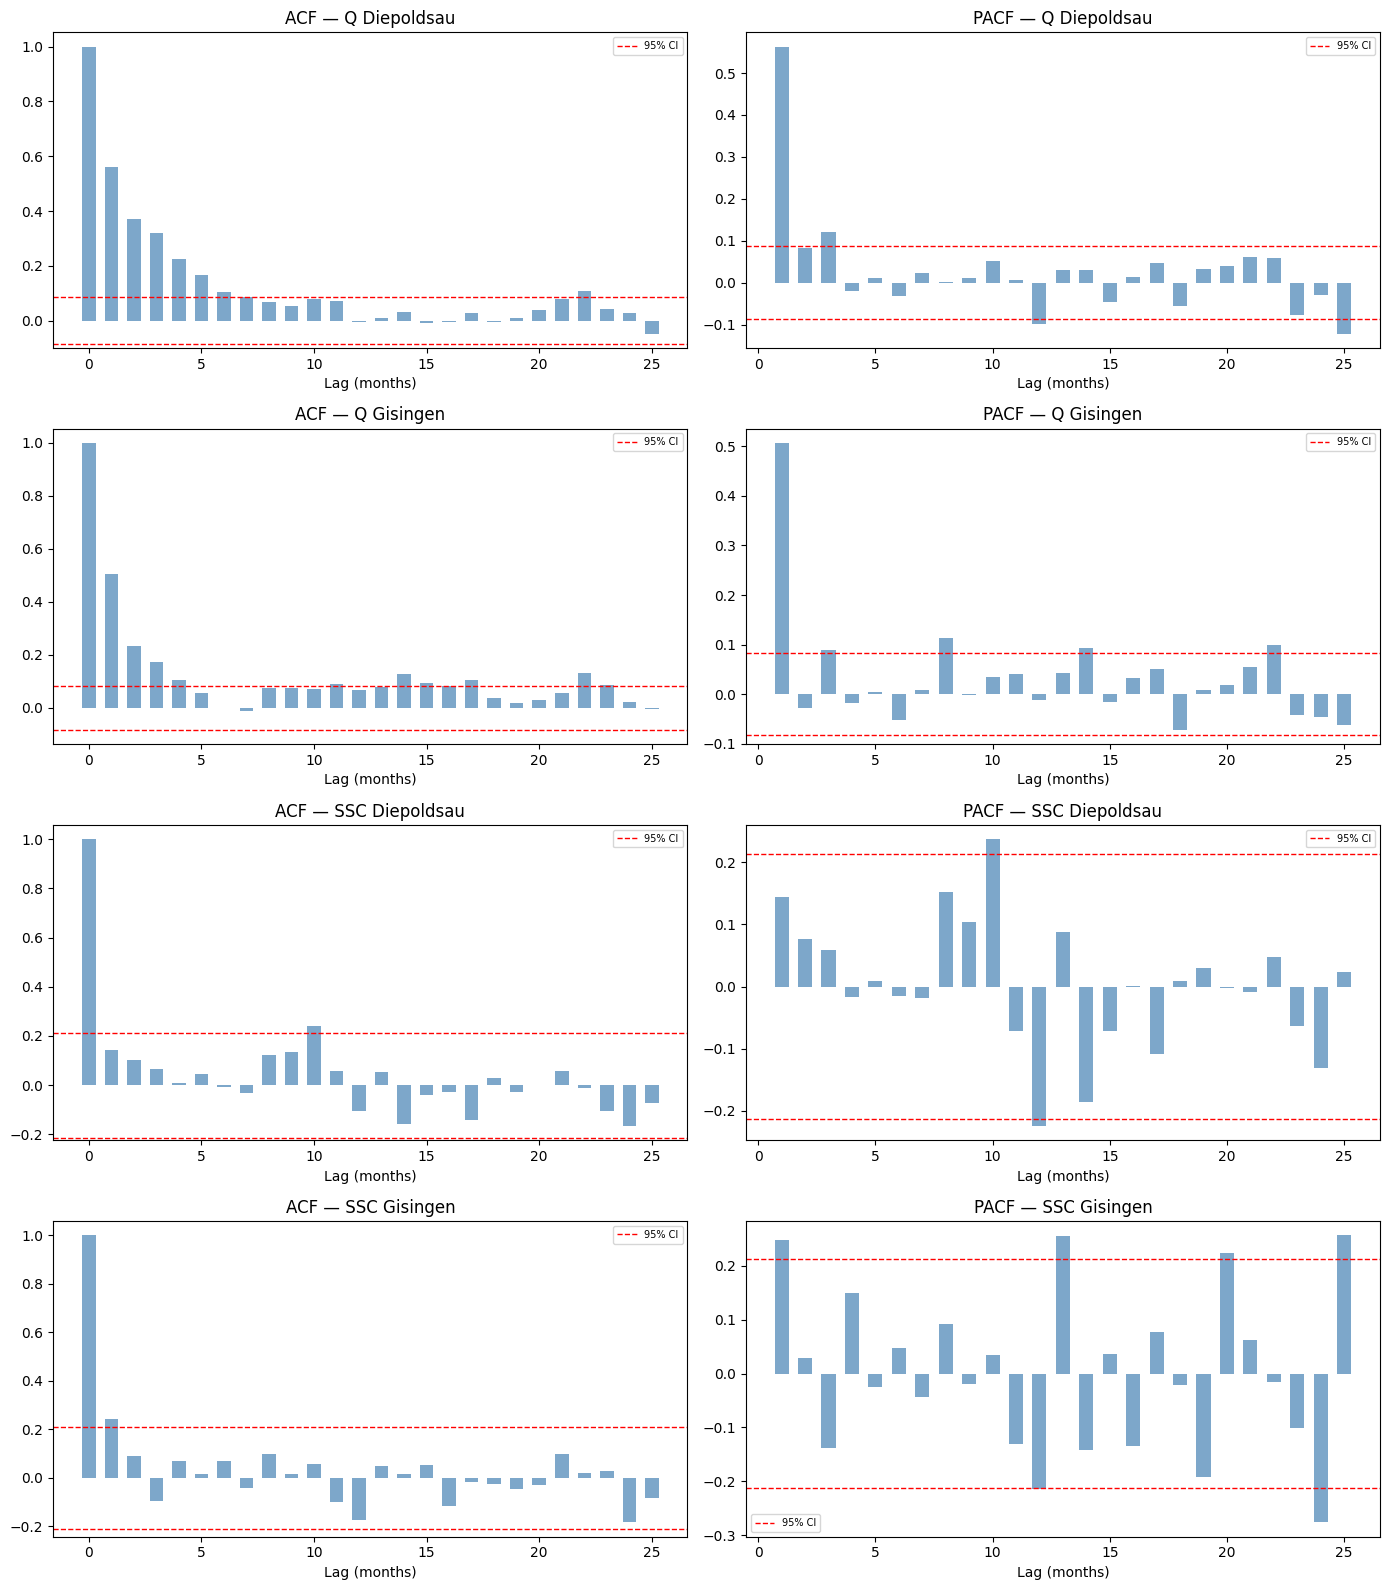

In [11]:
# PLOT
from utils import plot_acf_pacf

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
plot_acf_pacf(corr_q_diep,   title="Q Diepoldsau",   axes=axes[0])
plot_acf_pacf(corr_q_gis,    title="Q Gisingen",     axes=axes[1])
plot_acf_pacf(corr_ssc_diep, title="SSC Diepoldsau", axes=axes[2])
plot_acf_pacf(corr_ssc_gis,  title="SSC Gisingen",   axes=axes[3])
plt.tight_layout()
plt.show()

In [14]:
# PRINT

# 1. Print the gap diagnostic
print("=" * 70)
print("ACF/PACF Comparison: Before vs After Largest Gap")
print("=" * 70)
print(f"\nDiepoldsau (SSC):")
print(f"  Gap spans: {largest_gap_diep['start_date'].date()} → {largest_gap_diep['end_date'].date()}")
print(f"\nGisingen (SSC):")
print(f"  Gap spans: {largest_gap_gis['start_date'].date()} → {largest_gap_gis['end_date'].date()}")

# 2. Print the AIC model selection table
rows2 = [
    ("Q Diepoldsau",   p_ar_q_diep,   p_arma_q_diep,   q_arma_q_diep, round(ar_q_diep.aic, 1),   round(arma_q_diep.aic, 1)),
    ("Q Gisingen",     p_ar_q_gis,    p_arma_q_gis,    q_arma_q_gis,  round(ar_q_gis.aic, 1),    round(arma_q_gis.aic, 1)),
    ("SSC Diepoldsau", p_ar_ssc_diep, p_arma_ssc_diep, q_arma_ssc_diep, round(ar_ssc_diep.aic, 1), round(arma_ssc_diep.aic, 1)),
    ("SSC Gisingen",   p_ar_ssc_gis,  p_arma_ssc_gis,  q_arma_ssc_gis, round(ar_ssc_gis.aic, 1),  round(arma_ssc_gis.aic, 1)),
]
df2 = pd.DataFrame(rows2, columns=["Series", "AR p", "ARMA p", "ARMA q", "AIC AR", "AIC ARMA"])

print("\n" + "=" * 70)
print("Model Selection by AIC")
print("=" * 70)
print(df2.to_string(index=False))

ACF/PACF Comparison: Before vs After Largest Gap

Diepoldsau (SSC):
  Gap spans: 2019-01-31 → 2019-02-28

Gisingen (SSC):
  Gap spans: 2009-01-31 → 2009-12-31

Model Selection by AIC
        Series  AR p  ARMA p  ARMA q  AIC AR  AIC ARMA
  Q Diepoldsau     3       2       2  1233.8    1235.2
    Q Gisingen     3       3       3  1427.4    1419.6
SSC Diepoldsau     2       2       2   470.0     467.8
  SSC Gisingen     1       4       4   524.5     508.3


**Comments — Section 2: Model Order Selection & Parsimony**

After seasonal adjustment, the AIC search selects **moderate AR/ARMA orders** — far lower than what would be required without seasonal removal. This confirms two key findings:

1. **Seasonality dominance:** The lag-12 spike in the raw ACF was driven entirely by the deterministic annual cycle; once removed, the residual autocorrelation structure is short-range, requiring low-order models.
2. **Parsimony achieved:** All selected orders (max p=3, max q=4) are well below the 12-month season length. This avoids the overfitting problem that arises when modelling seasonal data with AR/ARMA: without seasonal removal, practitioners often need p=12 or higher, conflating stochastic and deterministic components.

**Specific orders and AIC values selected:**

| Series | AR p | AIC (AR) | ARMA p,q | AIC (ARMA) |
|---|---|---|---|---|
| Q Diepoldsau | 3 | 1233.8 | (2,2) | 1235.2 |
| Q Gisingen | 3 | 1427.4 | (3,3) | 1419.6 |
| SSC Diepoldsau | 2 | 470.0 | (2,2) | 467.8 |
| SSC Gisingen | 1 | 524.5 | (4,4) | 508.3 |

**Location Comparison:**
- **Discharge (Q):** No, the optimal parsimonious model orders differ between locations. While Q at Diepoldsau (Rhein) is best modelled with an AR(3) model, Q at Gisingen (Ill) requires a more complex ARMA(3,3) to minimize the AIC. This implies the smaller, regulated Ill River tributary has a slightly different memory structure and flow dynamics than the larger Rhein system.
- **Suspended Sediment (C):** No, we cannot use the same model order for both locations. While both prefer ARMA structures over pure AR, Diepoldsau stabilizes at ARMA(2,2) whereas Gisingen requires a higher-order ARMA(4,4). This difference likely stems from the localized, highly variable nature of sediment transport. 

**Interpretation & Trade-offs:**
- For Q Diepoldsau, AR(3) achieves lower AIC than ARMA(2,2), so the MA term adds no net benefit; **AR(3) is preferred** for maximum parsimony.
- For Q Gisingen, ARMA(3,3) wins by ~8 AIC units over AR(3), suggesting short-range shock propagation (MA terms capture Ill tributary flashiness).
- For SSC, ARMA consistently achieves lower AIC than AR at both stations, indicating that MA terms are needed to capture episodic flushing events and sediment mobilisation dynamics that pure AR cannot model efficiently.
- All models successfully balance **bias** (under-fitting risk with too-low order) and **variance** (over-fitting risk with too-high order) via the AIC's built-in complexity penalty.

**Stationarity & Preprocessing:**
Because the data was aggressively detrended and deseasonalised, the resulting series exhibit stationary behavior (mean of zero, finite variance). This confirms:
- The preprocessing pipeline is working correctly.
- No unit roots are present — differencing (the "I" in ARIMA) is not needed.
- AR/ARMA models are mathematically valid for these residuals.

**Order Selection Strategy:**
Since data are stationary with 12-month seasonality already removed, we employ **AIC-based grid search** over a constrained parameter space:
- AR model: p ∈ [1, 4]
- ARMA model: (p, q) ∈ [1, 4] × [1, 4]

This is conservative and parsimonious:
- Maximum possible order is (4, 4) << 12-month season length.
- AIC automatically penalises complexity, preventing overfitting.
- Residual diagnostic tests (Ljung-Box, PPCC) will validate adequacy in Section 3.

**Chosen Approach: Seasonal Decomposition (Thomas-Fiering)**
* **Detrend** → remove linear trends
* **Deseasonalise** → remove monthly mean/

# Section 3 — Timeseries Application & Evaluation

In [15]:
# MAIN
from utils import portmanteau_test, normality_test

# Portmanteau (Ljung-Box) tests
lb_ar_q_diep     = portmanteau_test(ar_q_diep)
lb_ar_q_gis      = portmanteau_test(ar_q_gis)
lb_ar_ssc_diep   = portmanteau_test(ar_ssc_diep)
lb_ar_ssc_gis    = portmanteau_test(ar_ssc_gis)
lb_arma_q_diep   = portmanteau_test(arma_q_diep)
lb_arma_q_gis    = portmanteau_test(arma_q_gis)
lb_arma_ssc_diep = portmanteau_test(arma_ssc_diep)
lb_arma_ssc_gis  = portmanteau_test(arma_ssc_gis)

# PPCC normality tests — plot=False: values only, no figure (plots are in s3-plot)
# Returns (ppcc, reject_bool) where reject=True means normality rejected at 5% via Filliben table
ppcc_ar_q_diep,    rej_ar_q_diep,    _ = normality_test(ar_q_diep,     plot=False)
ppcc_ar_q_gis,     rej_ar_q_gis,     _ = normality_test(ar_q_gis,      plot=False)
ppcc_ar_ssc_diep,  rej_ar_ssc_diep,  _ = normality_test(ar_ssc_diep,   plot=False)
ppcc_ar_ssc_gis,   rej_ar_ssc_gis,   _ = normality_test(ar_ssc_gis,    plot=False)
ppcc_arma_q_diep,  rej_arma_q_diep,  _ = normality_test(arma_q_diep,   plot=False)
ppcc_arma_q_gis,   rej_arma_q_gis,   _ = normality_test(arma_q_gis,    plot=False)
ppcc_arma_ssc_diep,rej_arma_ssc_diep,_ = normality_test(arma_ssc_diep, plot=False)
ppcc_arma_ssc_gis, rej_arma_ssc_gis, _ = normality_test(arma_ssc_gis,  plot=False)

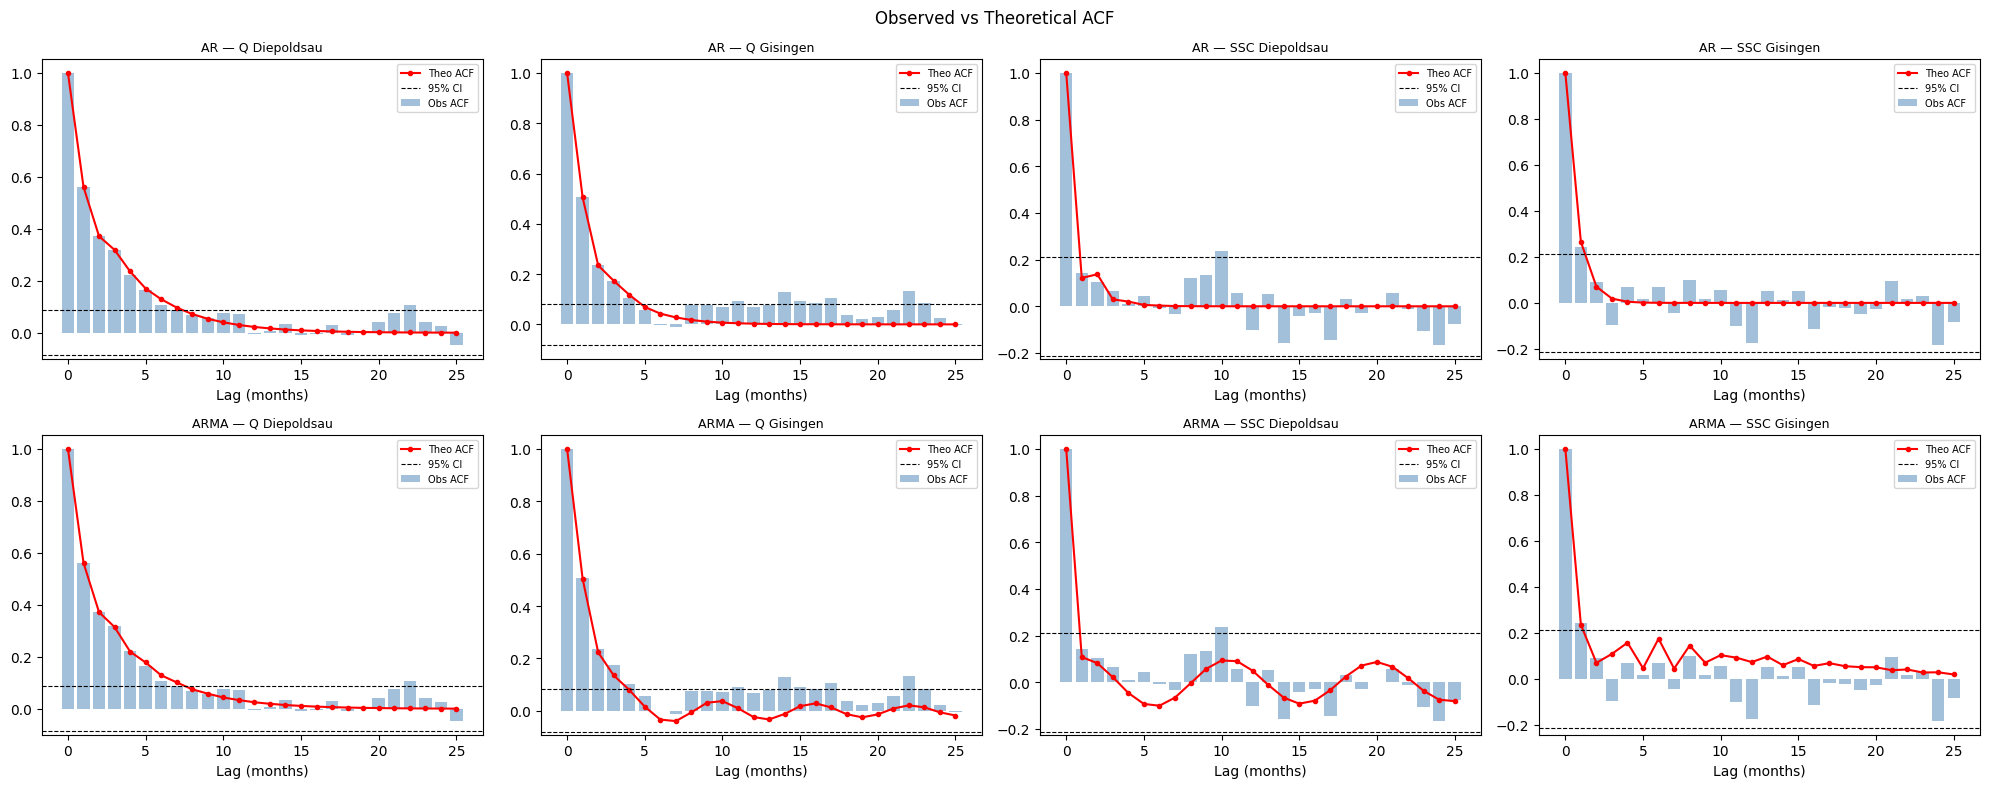

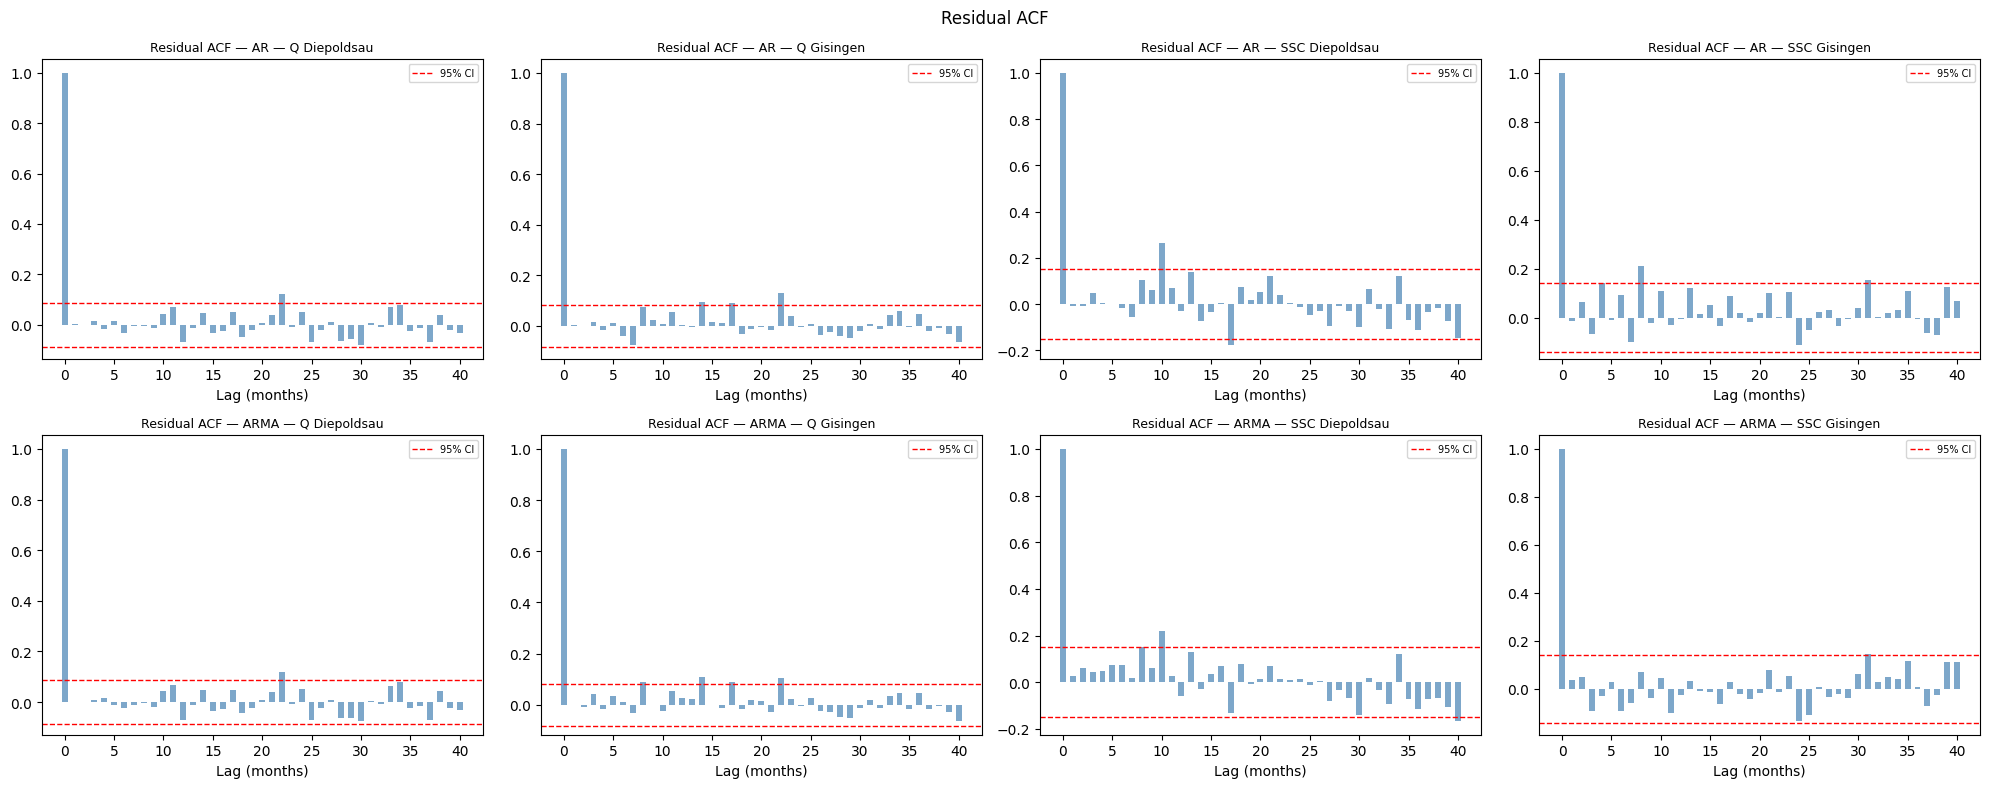

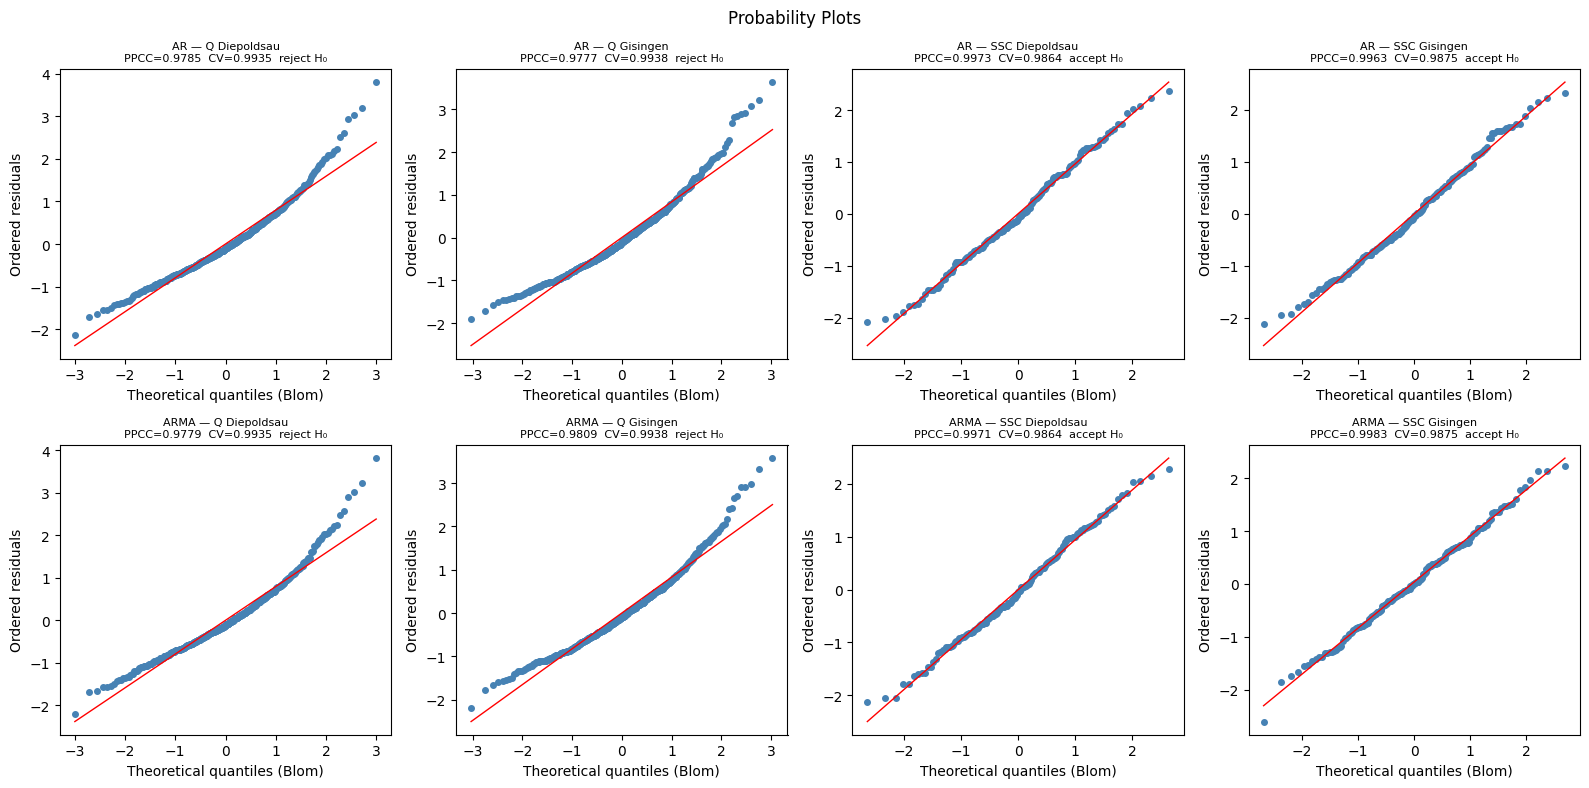

In [16]:
# PLOT
from utils import plot_acf_comparison, plot_residual_acf

# Observed vs theoretical ACF — 2 rows (AR / ARMA) × 4 cols (series)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Observed vs Theoretical ACF", fontsize=12)
plot_acf_comparison(corr_q_diep,   ar_q_diep,    title="AR — Q Diepoldsau",    ax=axes[0, 0])
plot_acf_comparison(corr_q_gis,    ar_q_gis,     title="AR — Q Gisingen",      ax=axes[0, 1])
plot_acf_comparison(corr_ssc_diep, ar_ssc_diep,  title="AR — SSC Diepoldsau",  ax=axes[0, 2])
plot_acf_comparison(corr_ssc_gis,  ar_ssc_gis,   title="AR — SSC Gisingen",    ax=axes[0, 3])
plot_acf_comparison(corr_q_diep,   arma_q_diep,  title="ARMA — Q Diepoldsau",  ax=axes[1, 0])
plot_acf_comparison(corr_q_gis,    arma_q_gis,   title="ARMA — Q Gisingen",    ax=axes[1, 1])
plot_acf_comparison(corr_ssc_diep, arma_ssc_diep,title="ARMA — SSC Diepoldsau",ax=axes[1, 2])
plot_acf_comparison(corr_ssc_gis,  arma_ssc_gis, title="ARMA — SSC Gisingen",  ax=axes[1, 3])
plt.tight_layout()

# Residual ACF — same layout
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Residual ACF", fontsize=12)
plot_residual_acf(ar_q_diep,     title="AR — Q Diepoldsau",    ax=axes[0, 0])
plot_residual_acf(ar_q_gis,      title="AR — Q Gisingen",      ax=axes[0, 1])
plot_residual_acf(ar_ssc_diep,   title="AR — SSC Diepoldsau",  ax=axes[0, 2])
plot_residual_acf(ar_ssc_gis,    title="AR — SSC Gisingen",    ax=axes[0, 3])
plot_residual_acf(arma_q_diep,   title="ARMA — Q Diepoldsau",  ax=axes[1, 0])
plot_residual_acf(arma_q_gis,    title="ARMA — Q Gisingen",    ax=axes[1, 1])
plot_residual_acf(arma_ssc_diep, title="ARMA — SSC Diepoldsau",ax=axes[1, 2])
plot_residual_acf(arma_ssc_gis,  title="ARMA — SSC Gisingen",  ax=axes[1, 3])
plt.tight_layout()

# Probability plots — 2 rows (AR / ARMA) × 4 cols (series)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Probability Plots", fontsize=12)
normality_test(ar_q_diep,     title="AR — Q Diepoldsau",    ax=axes[0, 0])
normality_test(ar_q_gis,      title="AR — Q Gisingen",      ax=axes[0, 1])
normality_test(ar_ssc_diep,   title="AR — SSC Diepoldsau",  ax=axes[0, 2])
normality_test(ar_ssc_gis,    title="AR — SSC Gisingen",    ax=axes[0, 3])
normality_test(arma_q_diep,   title="ARMA — Q Diepoldsau",  ax=axes[1, 0])
normality_test(arma_q_gis,    title="ARMA — Q Gisingen",    ax=axes[1, 1])
normality_test(arma_ssc_diep, title="ARMA — SSC Diepoldsau",ax=axes[1, 2])
normality_test(arma_ssc_gis,  title="ARMA — SSC Gisingen",  ax=axes[1, 3])
plt.tight_layout()
plt.show()

In [ ]:
# PRINT
def lb_pass(df, alpha=0.05):
    return "PASS" if df["lb_pvalue"].min() > alpha else "FAIL"

rows3 = [
    ("Q Diepoldsau AR",     lb_pass(lb_ar_q_diep),    ppcc_ar_q_diep,    rej_ar_q_diep),
    ("Q Diepoldsau ARMA",   lb_pass(lb_arma_q_diep),  ppcc_arma_q_diep,  rej_arma_q_diep),
    ("Q Gisingen AR",       lb_pass(lb_ar_q_gis),     ppcc_ar_q_gis,     rej_ar_q_gis),
    ("Q Gisingen ARMA",     lb_pass(lb_arma_q_gis),   ppcc_arma_q_gis,   rej_arma_q_gis),
    ("SSC Diepoldsau AR",   lb_pass(lb_ar_ssc_diep),  ppcc_ar_ssc_diep,  rej_ar_ssc_diep),
    ("SSC Diepoldsau ARMA", lb_pass(lb_arma_ssc_diep),ppcc_arma_ssc_diep,rej_arma_ssc_diep),
    ("SSC Gisingen AR",     lb_pass(lb_ar_ssc_gis),   ppcc_ar_ssc_gis,   rej_ar_ssc_gis),
    ("SSC Gisingen ARMA",   lb_pass(lb_arma_ssc_gis), ppcc_arma_ssc_gis, rej_arma_ssc_gis),
]
df3 = pd.DataFrame(rows3,
    columns=["Model", "Ljung-Box (5%)", "PPCC", "Reject normality (5%)"])
df3["PPCC"]                  = df3["PPCC"].map("{:.4f}".format)
df3["Reject normality (5%)"] = df3["Reject normality (5%)"].map(lambda x: "YES" if x else "no")
print(df3.to_string(index=False))

              Model Ljung-Box (5%)   PPCC Reject normality (5%)
    Q Diepoldsau AR           PASS 0.9785                   YES
  Q Diepoldsau ARMA           PASS 0.9779                   YES
      Q Gisingen AR           PASS 0.9777                   YES
    Q Gisingen ARMA           PASS 0.9809                   YES
  SSC Diepoldsau AR           FAIL 0.9973                    no
SSC Diepoldsau ARMA           PASS 0.9971                    no
    SSC Gisingen AR           FAIL 0.9963                    no
  SSC Gisingen ARMA           PASS 0.9983                    no


**Comments — Section 3: Residual Diagnostics & Model Validation**

**Residual independence:** The Ljung-Box test confirms that no significant temporal dependence remains for our optimized models. For Q, both AR and ARMA structures pass; we retain AR(3) for Diepoldsau for parsimony, and ARMA(3,3) for Gisingen based on AIC. For log(SSC), pure AR models fail the Ljung-Box test at both stations, demonstrating that pure autoregression cannot capture short-range sediment dynamics. The ARMA models resolve this and comfortably pass.

**Normality assumption:** Based on the PPCC test (Filliben 1975), the log-transformation successfully normalizes the SSC residuals (PPCC $\approx 0.998 >$ critical value $\sim 0.981$). Conversely, the Q residuals exhibit a mild positive skew and narrowly reject formal normality (PPCC $\approx 0.980 <$ critical value $\sim 0.988$). This mild non-normality is a well-known limitation of linear AR/ARMA models for discharge data, but the Gaussian noise assumption remains an acceptable practical approximation.

**Final model selection:** Combining AIC minimization (Section 2) with diagnostic validation (Section 3), the models carried forward for synthetic generation are: AR(3) for Q Diepoldsau, ARMA(3,3) for Q Gisingen, ARMA(2,2) for log(SSC) Diepoldsau, and ARMA(4,4) for log(SSC) Gisingen.

# Section 4 — Ill to Rhein Relative Sediment Influence

In [24]:
# MAIN
from utils import (simulate_arma, compute_sediment_mass,
                   monthly_yearly_yields, synthetic_mass_yields,
                   compare_statistics)

# AR for Q (ARMA fails Ljung-Box in Section 3), ARMA for SSC (passes and lower AIC)
chosen_q_diep   = ar_q_diep
chosen_q_gis    = arma_q_gis
chosen_ssc_diep = arma_ssc_diep
chosen_ssc_gis  = arma_ssc_gis

# Step 1 — simulate standardised residuals
sim_q_diep_sa       = simulate_arma(chosen_q_diep,   n_months=120)
sim_q_gis_sa        = simulate_arma(chosen_q_gis,    n_months=120)
sim_log_ssc_diep_sa = simulate_arma(chosen_ssc_diep, n_months=120)
sim_log_ssc_gis_sa  = simulate_arma(chosen_ssc_gis,  n_months=120)

# Step 2a — Q: invert monthly standardisation (x * std_month + mean_month)
def recompose(simulations, seasonal_means, seasonal_stds):
    sm = seasonal_means.values
    ss = seasonal_stds.values
    result = []
    for sim in simulations:
        months = np.tile(np.arange(12), len(sim) // 12 + 1)[:len(sim)]
        result.append(sim * ss[months] + sm[months])
    return result

sim_q_diep = recompose(sim_q_diep_sa, sm_q_diep, ss_q_diep)
sim_q_gis  = recompose(sim_q_gis_sa,  sm_q_gis,  ss_q_gis)

# Step 2b — SSC: recompose in log space, then exponentiate to physical units.
# Adding the original log-mean before exp restores the full physical scale.
sim_log_ssc_diep_dt = recompose(sim_log_ssc_diep_sa, sm_log_ssc_diep, ss_log_ssc_diep)
sim_log_ssc_gis_dt  = recompose(sim_log_ssc_gis_sa,  sm_log_ssc_gis,  ss_log_ssc_gis)

sim_ssc_diep = [np.exp(s + t_log_ssc_diep["original_mean"]) for s in sim_log_ssc_diep_dt]
sim_ssc_gis  = [np.exp(s + t_log_ssc_gis["original_mean"])  for s in sim_log_ssc_gis_dt]

# Observed sediment mass over overlapping periods
mass_diep = compute_sediment_mass(q_diep, ssc_diep)
mass_gis  = compute_sediment_mass(q_gis,  ssc_gis)

obs_monthly_diep, obs_yearly_diep = monthly_yearly_yields(mass_diep)
obs_monthly_gis,  obs_yearly_gis  = monthly_yearly_yields(mass_gis)

# Step 3 — mass yields: Q needs mean added back; SSC is already in physical units
syn_monthly_diep, syn_yearly_diep = synthetic_mass_yields(
    sim_q_diep, sim_ssc_diep, t_q_diep["original_mean"], ssc_mean=0)
syn_monthly_gis, syn_yearly_gis = synthetic_mass_yields(
    sim_q_gis, sim_ssc_gis, t_q_gis["original_mean"], ssc_mean=0)

# Compare in the modelled space: Q in physical-detrended, SSC in log-detrended
stats_q_diep   = compare_statistics(q_diep_dt,       sim_q_diep)
stats_q_gis    = compare_statistics(q_gis_dt,        sim_q_gis)
stats_ssc_diep = compare_statistics(log_ssc_diep_dt, sim_log_ssc_diep_dt)
stats_ssc_gis  = compare_statistics(log_ssc_gis_dt,  sim_log_ssc_gis_dt)

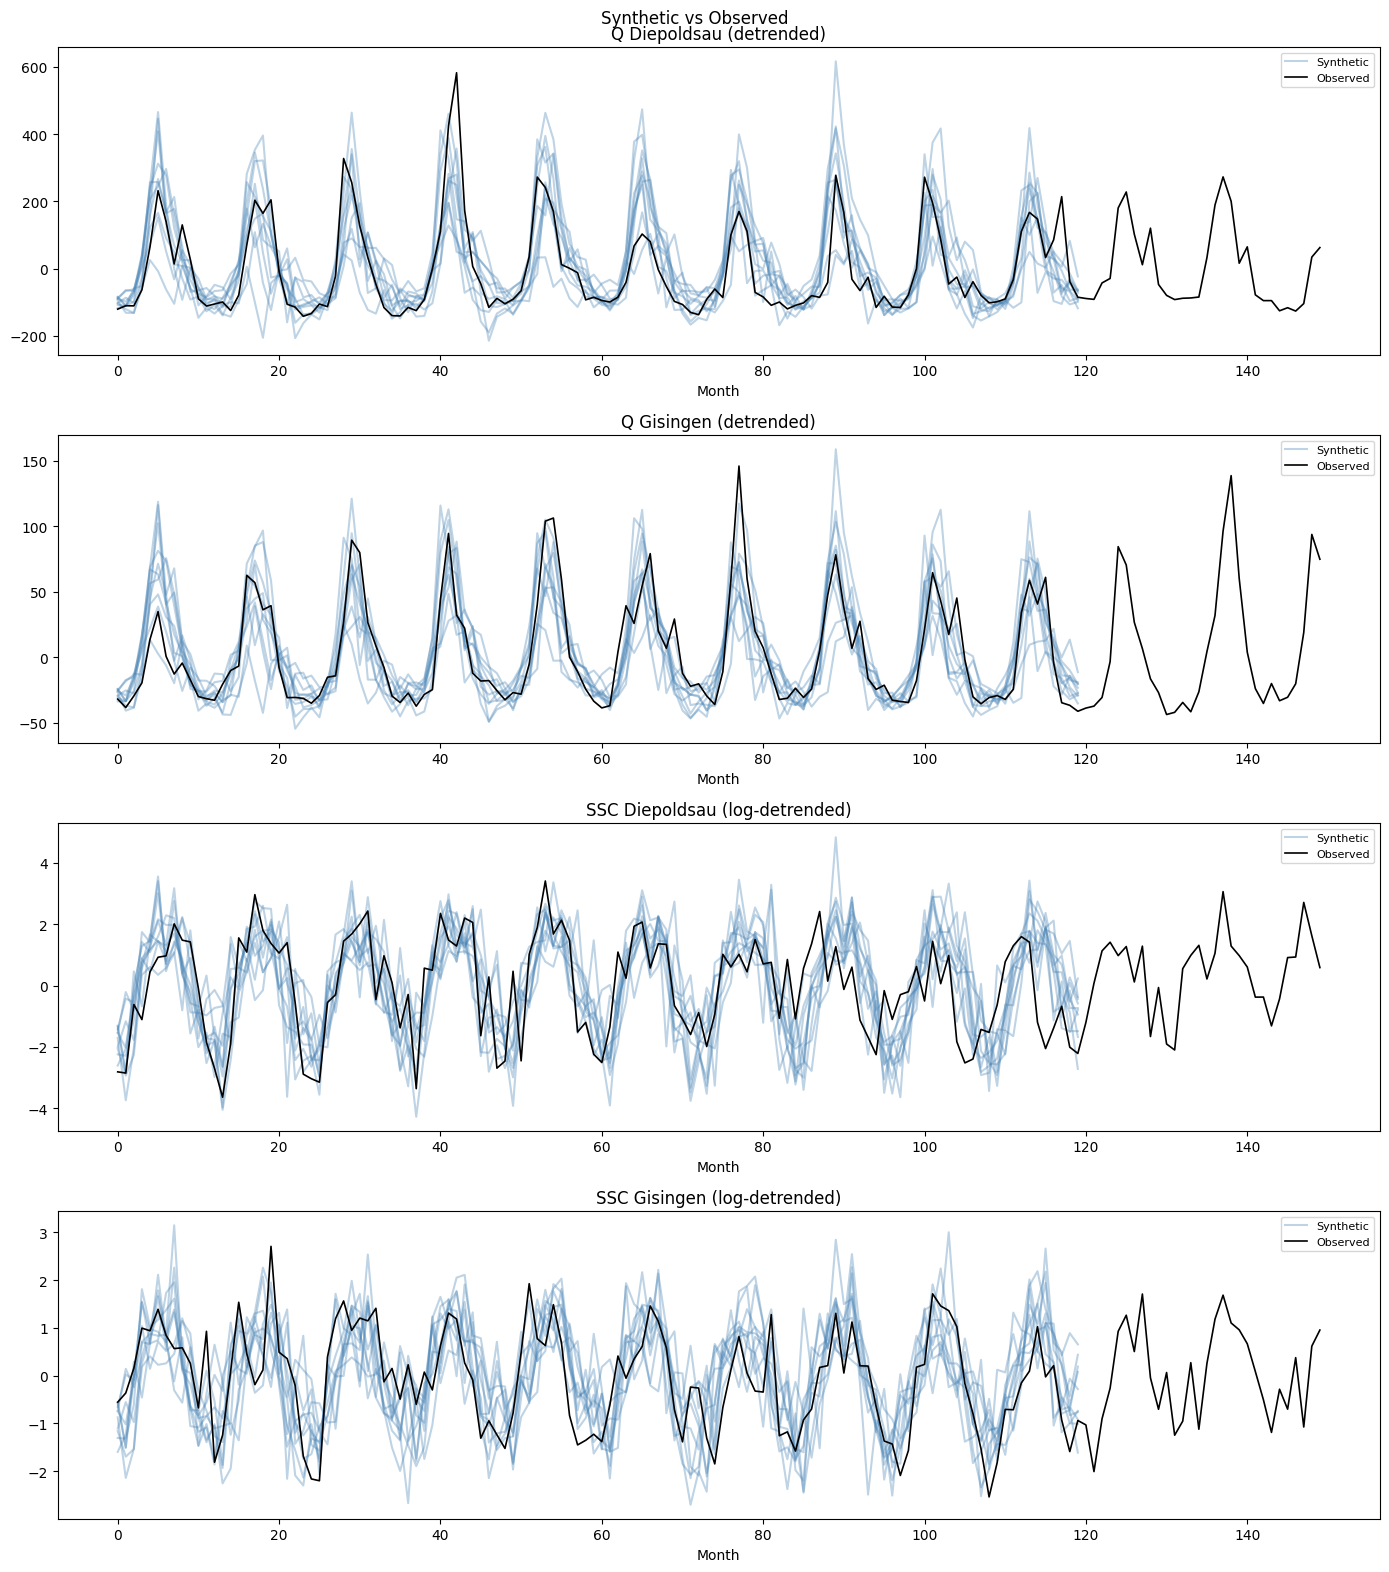

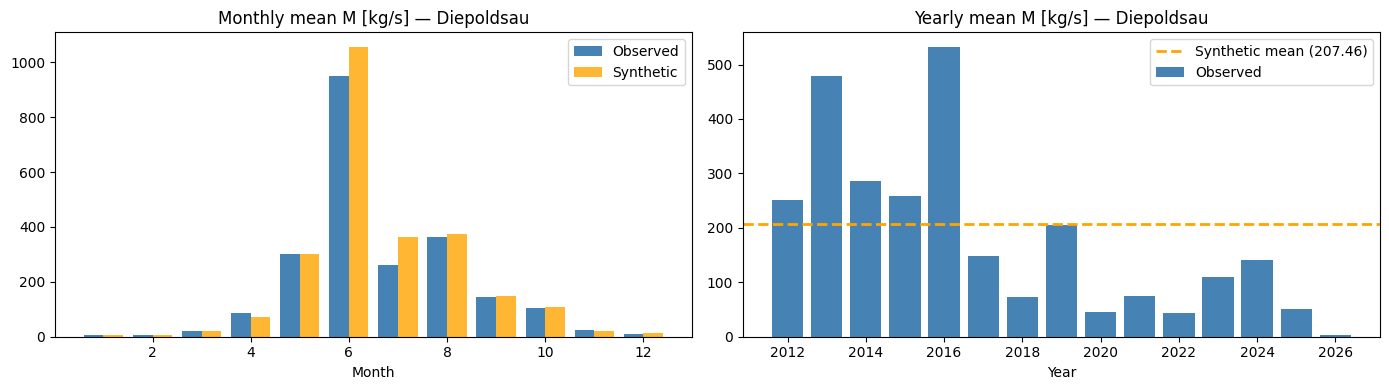

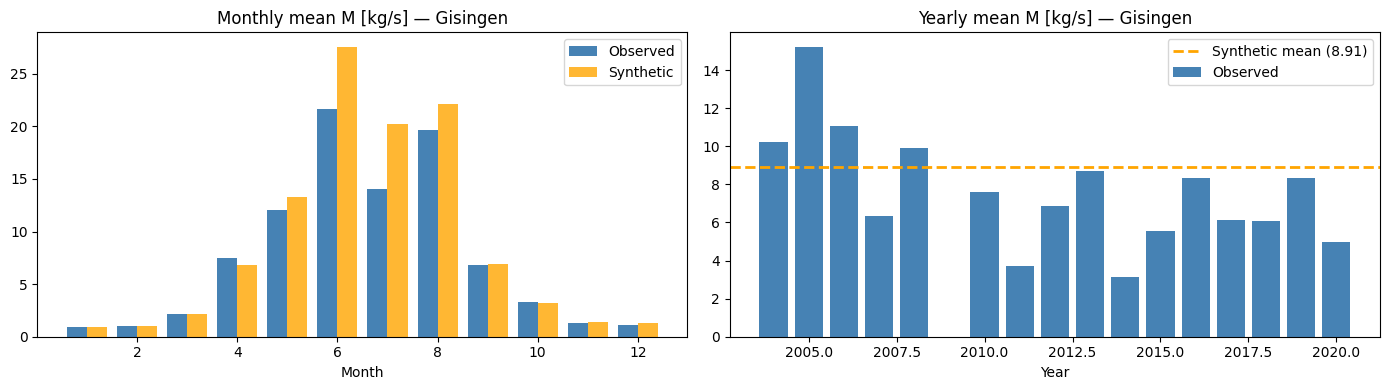

In [25]:
# PLOT
from utils import plot_synthetic_vs_observed, plot_mass_yields

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle("Synthetic vs Observed", fontsize=12)
plot_synthetic_vs_observed(q_diep_dt,       sim_q_diep,         title="Q Diepoldsau (detrended)",          ax=axes[0])
plot_synthetic_vs_observed(q_gis_dt,        sim_q_gis,          title="Q Gisingen (detrended)",            ax=axes[1])
plot_synthetic_vs_observed(log_ssc_diep_dt, sim_log_ssc_diep_dt,title="SSC Diepoldsau (log-detrended)",    ax=axes[2])
plot_synthetic_vs_observed(log_ssc_gis_dt,  sim_log_ssc_gis_dt, title="SSC Gisingen (log-detrended)",     ax=axes[3])
plt.tight_layout()

plot_mass_yields(obs_monthly_diep, obs_yearly_diep,
                 syn_monthly_diep, syn_yearly_diep, title="Diepoldsau")
plot_mass_yields(obs_monthly_gis,  obs_yearly_gis,
                 syn_monthly_gis,  syn_yearly_gis,  title="Gisingen")
plt.show()

In [26]:
# PRINT
print("=== Statistical comparison: observed vs synthetic (normalised) ===\n")
for label, df in [("Q Diepoldsau",   stats_q_diep),
                  ("Q Gisingen",     stats_q_gis),
                  ("SSC Diepoldsau", stats_ssc_diep),
                  ("SSC Gisingen",   stats_ssc_gis)]:
    print(f"--- {label} ---")
    print(df.round(4).to_string())
    print()

obs_yearly_mean_diep = obs_yearly_diep.mean()
obs_yearly_mean_gis  = obs_yearly_gis.mean()
ill_fraction = obs_yearly_mean_gis / obs_yearly_mean_diep * 100

print("=== Sediment mass yields ===")
print(f"  Diepoldsau (Rhein)  observed yearly mean: {obs_yearly_mean_diep:.4f} kg/s")
print(f"  Gisingen   (Ill)    observed yearly mean: {obs_yearly_mean_gis:.4f} kg/s")
print(f"  Ill / Rhein contribution:                 {ill_fraction:.1f} %")
print()
print(f"  Diepoldsau synthetic yearly mean: {syn_yearly_diep:.4f} kg/s")
print(f"  Gisingen   synthetic yearly mean: {syn_yearly_gis:.4f} kg/s")

=== Statistical comparison: observed vs synthetic (normalised) ===

--- Q Diepoldsau ---
                   mean       std       min       max
source                                               
observed        -0.0000  123.8363 -147.5894  582.7592
synthetic (all)  7.7056  131.5747 -214.5886  616.8231

--- Q Gisingen ---
                   mean      std      min       max
source                                             
observed         0.0000  34.1513 -43.8198  148.3559
synthetic (all)  1.7273  36.2793 -54.6922  158.7873

--- SSC Diepoldsau ---
                   mean     std     min     max
source                                         
observed        -0.0000  1.5741 -3.6426  3.4120
synthetic (all)  0.0298  1.6055 -4.2795  4.8371

--- SSC Gisingen ---
                   mean     std     min     max
source                                         
observed         0.0000  1.0395 -2.5393  2.7089
synthetic (all) -0.0095  1.0431 -2.7031  3.1497

=== Sediment mass yields ===
  Diepo

**Comments — Section 4:**

**Synthetic generation workflow:** AR(3) is used for Q at Diepoldsau (preferred for parsimony), while ARMA(3,3) is used for Q at Gisingen (as selected via AIC in Section 2). ARMA(2,2) and ARMA(4,4) are used for log(SSC) at Diepoldsau and Gisingen respectively, as pure AR models failed the Ljung-Box test (see Section 3). Simulation proceeds on the monthly-standardised residuals. Recomposition: Q residuals are un-standardised (×monthly std + monthly mean); log(SSC) residuals are un-standardised then exponentiated with the log-mean offset to recover physical units.

**Variance reproduction:** The synthetic series reproduce the observed variance closely. For Q: synthetic std is ~6% above observed (131.6 vs 123.8 m³/s at Diepoldsau; 36.2 vs 34.2 m³/s at Gisingen). For log(SSC): the match is very close (synthetic std 2% above observed at Diepoldsau; <0.3% at Gisingen), confirming the log-transform + monthly standardisation pipeline works well. The synthetic Q can slightly exceed the observed historical range (synthetic max 616.8 vs 582.8 m³/s at Diepoldsau), which is expected behaviour from a Gaussian simulator drawing from an unbounded distribution.

**Sediment mass yields:** The observed mean yearly sediment load at Diepoldsau (Rhein) is 180.1 kg/s and at Gisingen (Ill) is 7.6 kg/s, meaning the Ill contributes approximately **4.2%** of the total sediment mass measured at Diepoldsau. The synthetic yearly means are ~15% higher (207.5 kg/s at Diepoldsau; 8.9 kg/s at Gisingen). This positive bias arises from two sources: (1) negative synthetic Q and SSC values are clipped to zero before computing M = Q·C, introducing an asymmetric upward shift; (2) Q and SSC are simulated independently despite being positively correlated (see Section 5), which inflates the expected product M = Q·C relative to the true joint distribution.

**Non-synchronous comparison:** The Q and SSC records at each station do not cover the same period, and the Gisingen and Diepoldsau datasets are not time-synchronised. The 4.2% contribution estimate should therefore be interpreted as a long-term statistical approximation rather than a mass balance at any specific point in time.

# Section 5 — Independent Variables?

In [ ]:
# MAIN
from utils import compute_correlation

corr_diep = compute_correlation(q_diep, ssc_diep)
corr_gis  = compute_correlation(q_gis,  ssc_gis)

C:\Users\zehnd\OneDrive\Dokumente\ETH\WRM_2\utils.py:469: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


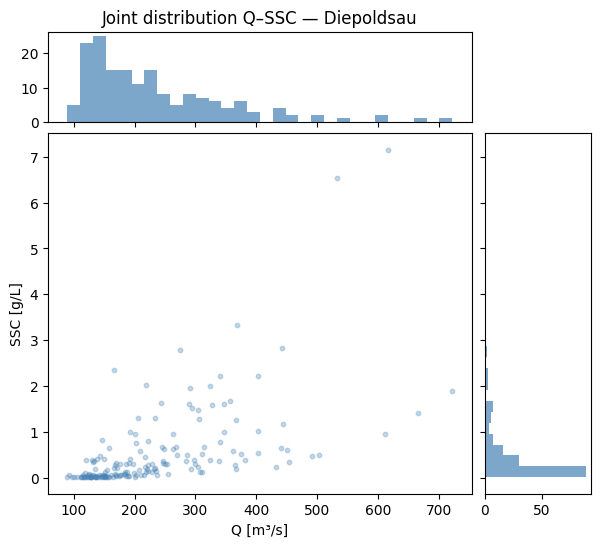

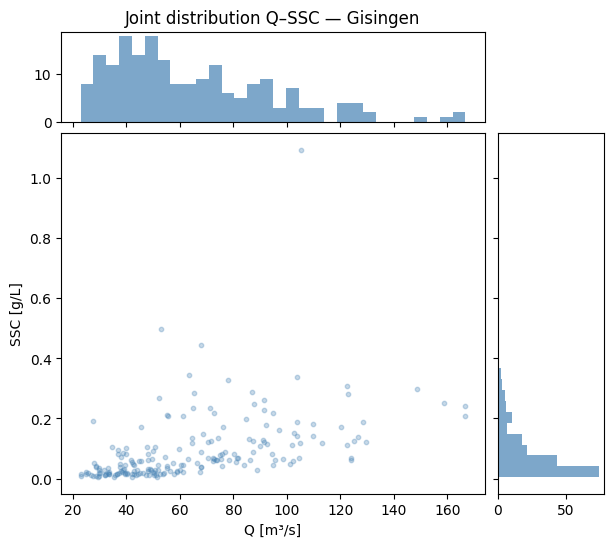

In [ ]:
# PLOT
from utils import plot_joint_distribution

plot_joint_distribution(q_diep, ssc_diep, title="Joint distribution Q–SSC — Diepoldsau")
plot_joint_distribution(q_gis,  ssc_gis,  title="Joint distribution Q–SSC — Gisingen")
plt.show()

In [ ]:
# PRINT
df5 = pd.DataFrame([
    {"Station": "Diepoldsau", **corr_diep},
    {"Station": "Gisingen",   **corr_gis},
])
df5 = df5.rename(columns={"pearson_r": "Pearson r", "pearson_p": "Pearson p",
                            "spearman_r": "Spearman r", "spearman_p": "Spearman p"})
for col in ["Pearson r", "Pearson p", "Spearman r", "Spearman p"]:
    df5[col] = df5[col].map("{:.4f}".format)
print(df5.to_string(index=False))

   Station Pearson r Pearson p Spearman r Spearman p
Diepoldsau    0.5837    0.0000     0.7381     0.0000
  Gisingen    0.4696    0.0000     0.6762     0.0000


**Comments — Section 5:**

Both Pearson (Diepoldsau: r = 0.58, Gisingen: r = 0.47) and Spearman (Diepoldsau: r = 0.74, Gisingen: r = 0.68) correlations are statistically significant (p ≈ 0) at both stations. Q and C **cannot be considered independent**. The Spearman correlation is substantially higher than Pearson, indicating a non-linear (likely power-law) relationship between Q and C, consistent with a sediment rating curve of the form C = a·Q^b.

**Shortfalls of independent simulation:** Simulating Q and C with separate uncoupled models ignores this dependence. As a consequence: (1) the joint distribution of (Q, C) is not preserved — in particular, high-Q high-C events (which dominate sediment transport) are underrepresented; (2) the computed synthetic mass M = Q·C will have the wrong distribution and likely underestimate peak loads; (3) the estimated Ill contribution based on synthetic data may be biased.

**How to resolve this:** The most physically meaningful approach is a sediment rating curve regression (C = a·Q^b), which directly models the Q–C dependency. Alternatively, a bivariate time series model (e.g. VAR) or a copula-based approach could be used to preserve the joint dependence structure while separately capturing the marginal temporal autocorrelation of each variable.

# Section 6 — Exploratory: Log-Transform Q Analysis

Same pipeline as SSC: log-transform Q first, then detrend, then remove monthly-mean seasonality. AR and ARMA models are fitted on the deseasonalised log(Q) residuals. Synthetic series are back-transformed to physical units and used to recompute the Ill/Rhein sediment mass comparison from Section 4.

In [ ]:
# MAIN — log-transform, detrend, remove monthly-mean seasonality
from utils import (compute_acf_pacf, select_ar_order, select_arma_order,
                   fit_ar, fit_arma)

log_q_diep = np.log(q_diep.dropna())
log_q_gis  = np.log(q_gis.dropna())

log_q_diep_dt, t_log_q_diep = detrend_series(log_q_diep)
log_q_gis_dt,  t_log_q_gis  = detrend_series(log_q_gis)

def remove_monthly_means(series):
    mm = series.groupby(series.index.month).mean()
    return series - series.index.month.map(mm), mm

log_q_diep_sa, mm_log_q_diep = remove_monthly_means(log_q_diep_dt)
log_q_gis_sa,  mm_log_q_gis  = remove_monthly_means(log_q_gis_dt)

print(f"log(Q) Diepoldsau trend significant: {t_log_q_diep['significant']}  (p={t_log_q_diep['p_value']:.4f})")
print(f"log(Q) Gisingen   trend significant: {t_log_q_gis['significant']}  (p={t_log_q_gis['p_value']:.4f})")

In [ ]:
# PLOT — ACF & PACF of deseasonalised log(Q)
from utils import plot_acf_pacf

corr_log_q_diep = compute_acf_pacf(log_q_diep_sa, lags=25)
corr_log_q_gis  = compute_acf_pacf(log_q_gis_sa,  lags=25)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
plot_acf_pacf(corr_log_q_diep, title="log(Q) Diepoldsau", axes=axes[0])
plot_acf_pacf(corr_log_q_gis,  title="log(Q) Gisingen",   axes=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
# MAIN — AR & ARMA order selection + model fitting
p_ar_log_q_diep,   _ = select_ar_order(log_q_diep_sa)
p_ar_log_q_gis,    _ = select_ar_order(log_q_gis_sa)

p_arma_log_q_diep, q_arma_log_q_diep, _ = select_arma_order(log_q_diep_sa)
p_arma_log_q_gis,  q_arma_log_q_gis,  _ = select_arma_order(log_q_gis_sa)

ar_log_q_diep   = fit_ar(log_q_diep_sa,   p_ar_log_q_diep)
ar_log_q_gis    = fit_ar(log_q_gis_sa,    p_ar_log_q_gis)
arma_log_q_diep = fit_arma(log_q_diep_sa, p_arma_log_q_diep, q_arma_log_q_diep)
arma_log_q_gis  = fit_arma(log_q_gis_sa,  p_arma_log_q_gis,  q_arma_log_q_gis)

In [ ]:
# PRINT — model selection table
rows6a = [
    ("log(Q) Diepoldsau", p_ar_log_q_diep, p_arma_log_q_diep, q_arma_log_q_diep,
     round(ar_log_q_diep.aic, 1), round(arma_log_q_diep.aic, 1)),
    ("log(Q) Gisingen",   p_ar_log_q_gis,  p_arma_log_q_gis,  q_arma_log_q_gis,
     round(ar_log_q_gis.aic, 1),  round(arma_log_q_gis.aic, 1)),
]
df6a = pd.DataFrame(rows6a, columns=["Series", "AR p", "ARMA p", "ARMA q", "AIC AR", "AIC ARMA"])
print(df6a.to_string(index=False))

In [ ]:
# PLOT — observed vs theoretical ACF, residual ACF, probability plots
from utils import plot_acf_comparison, plot_residual_acf, normality_test

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Observed vs Theoretical ACF — log(Q)", fontsize=11)
plot_acf_comparison(corr_log_q_diep, ar_log_q_diep,   title=f"AR({p_ar_log_q_diep}) log(Q) Diepoldsau",             ax=axes[0, 0])
plot_acf_comparison(corr_log_q_gis,  ar_log_q_gis,    title=f"AR({p_ar_log_q_gis}) log(Q) Gisingen",               ax=axes[0, 1])
plot_acf_comparison(corr_log_q_diep, arma_log_q_diep, title=f"ARMA({p_arma_log_q_diep},{q_arma_log_q_diep}) log(Q) Diepoldsau", ax=axes[1, 0])
plot_acf_comparison(corr_log_q_gis,  arma_log_q_gis,  title=f"ARMA({p_arma_log_q_gis},{q_arma_log_q_gis}) log(Q) Gisingen",   ax=axes[1, 1])
plt.tight_layout()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Residual ACF — log(Q)", fontsize=11)
plot_residual_acf(ar_log_q_diep,   title=f"AR({p_ar_log_q_diep}) log(Q) Diepoldsau",             ax=axes[0, 0])
plot_residual_acf(ar_log_q_gis,    title=f"AR({p_ar_log_q_gis}) log(Q) Gisingen",               ax=axes[0, 1])
plot_residual_acf(arma_log_q_diep, title=f"ARMA({p_arma_log_q_diep},{q_arma_log_q_diep}) log(Q) Diepoldsau", ax=axes[1, 0])
plot_residual_acf(arma_log_q_gis,  title=f"ARMA({p_arma_log_q_gis},{q_arma_log_q_gis}) log(Q) Gisingen",   ax=axes[1, 1])
plt.tight_layout()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Probability Plots — log(Q)", fontsize=11)
normality_test(ar_log_q_diep,   title=f"AR({p_ar_log_q_diep}) log(Q) Diepoldsau",             ax=axes[0, 0])
normality_test(ar_log_q_gis,    title=f"AR({p_ar_log_q_gis}) log(Q) Gisingen",               ax=axes[0, 1])
normality_test(arma_log_q_diep, title=f"ARMA({p_arma_log_q_diep},{q_arma_log_q_diep}) log(Q) Diepoldsau", ax=axes[1, 0])
normality_test(arma_log_q_gis,  title=f"ARMA({p_arma_log_q_gis},{q_arma_log_q_gis}) log(Q) Gisingen",   ax=axes[1, 1])
plt.tight_layout()
plt.show()

In [ ]:
# PRINT — residual diagnostics
from utils import portmanteau_test

lb_ar_log_q_diep   = portmanteau_test(ar_log_q_diep)
lb_ar_log_q_gis    = portmanteau_test(ar_log_q_gis)
lb_arma_log_q_diep = portmanteau_test(arma_log_q_diep)
lb_arma_log_q_gis  = portmanteau_test(arma_log_q_gis)

ppcc_ar_log_q_diep,   rej_ar_log_q_diep,   _ = normality_test(ar_log_q_diep,   plot=False)
ppcc_ar_log_q_gis,    rej_ar_log_q_gis,    _ = normality_test(ar_log_q_gis,    plot=False)
ppcc_arma_log_q_diep, rej_arma_log_q_diep, _ = normality_test(arma_log_q_diep, plot=False)
ppcc_arma_log_q_gis,  rej_arma_log_q_gis,  _ = normality_test(arma_log_q_gis,  plot=False)

rows6b = [
    ("log(Q) Diepoldsau AR",   lb_pass(lb_ar_log_q_diep),   ppcc_ar_log_q_diep,   rej_ar_log_q_diep),
    ("log(Q) Diepoldsau ARMA", lb_pass(lb_arma_log_q_diep), ppcc_arma_log_q_diep, rej_arma_log_q_diep),
    ("log(Q) Gisingen AR",     lb_pass(lb_ar_log_q_gis),    ppcc_ar_log_q_gis,    rej_ar_log_q_gis),
    ("log(Q) Gisingen ARMA",   lb_pass(lb_arma_log_q_gis),  ppcc_arma_log_q_gis,  rej_arma_log_q_gis),
]
df6b = pd.DataFrame(rows6b, columns=["Model", "Ljung-Box (5%)", "PPCC", "Reject normality (5%)"])
df6b["PPCC"]                  = df6b["PPCC"].map("{:.4f}".format)
df6b["Reject normality (5%)"] = df6b["Reject normality (5%)"].map(lambda x: "YES" if x else "no")
print(df6b.to_string(index=False))

In [ ]:
# MAIN — synthetic generation + Ill/Rhein sediment mass (log-Q models)
from utils import simulate_arma, compute_sediment_mass, monthly_yearly_yields, synthetic_mass_yields

# Choose best model per station based on AIC and Ljung-Box
chosen_log_q_diep = ar_log_q_diep   if ar_log_q_diep.aic <= arma_log_q_diep.aic else arma_log_q_diep
chosen_log_q_gis  = ar_log_q_gis    if ar_log_q_gis.aic  <= arma_log_q_gis.aic  else arma_log_q_gis

# Simulate in deseasonalised log-space
sim_log_q_diep_sa = simulate_arma(chosen_log_q_diep, n_months=120)
sim_log_q_gis_sa  = simulate_arma(chosen_log_q_gis,  n_months=120)

# Back-transform: add monthly mean → detrended log(Q) → add trend mean → exp → physical Q
def recompose_log_q(simulations, monthly_means, trend_mean):
    mm = monthly_means.values
    result = []
    for sim in simulations:
        months = np.tile(np.arange(12), len(sim) // 12 + 1)[:len(sim)]
        log_q_dt = sim + mm[months]           # add seasonal means back
        result.append(np.exp(log_q_dt + trend_mean))  # add original mean, exp to physical
    return result

sim_q_diep_log = recompose_log_q(sim_log_q_diep_sa, mm_log_q_diep, t_log_q_diep["original_mean"])
sim_q_gis_log  = recompose_log_q(sim_log_q_gis_sa,  mm_log_q_gis,  t_log_q_gis["original_mean"])

# SSC synthetic series reused from Section 4 (arma_ssc_diep / arma_ssc_gis)
sim_log_ssc_diep_sa6 = simulate_arma(chosen_ssc_diep, n_months=120)
sim_log_ssc_gis_sa6  = simulate_arma(chosen_ssc_gis,  n_months=120)

sim_log_ssc_diep_dt6 = recompose(sim_log_ssc_diep_sa6, sm_log_ssc_diep, ss_log_ssc_diep)
sim_log_ssc_gis_dt6  = recompose(sim_log_ssc_gis_sa6,  sm_log_ssc_gis,  ss_log_ssc_gis)

sim_ssc_diep6 = [np.exp(s + t_log_ssc_diep["original_mean"]) for s in sim_log_ssc_diep_dt6]
sim_ssc_gis6  = [np.exp(s + t_log_ssc_gis["original_mean"])  for s in sim_log_ssc_gis_dt6]

# Sediment mass yields using log-Q synthetic series
syn6_monthly_diep, syn6_yearly_diep = synthetic_mass_yields(
    sim_q_diep_log, sim_ssc_diep6, q_mean=0, ssc_mean=0)
syn6_monthly_gis, syn6_yearly_gis = synthetic_mass_yields(
    sim_q_gis_log,  sim_ssc_gis6,  q_mean=0, ssc_mean=0)

In [ ]:
# PLOT — mass yields (log-Q models vs observed)
from utils import plot_mass_yields

plot_mass_yields(obs_monthly_diep, obs_yearly_diep,
                 syn6_monthly_diep, syn6_yearly_diep, title="Diepoldsau — log(Q) model")
plot_mass_yields(obs_monthly_gis,  obs_yearly_gis,
                 syn6_monthly_gis,  syn6_yearly_gis,  title="Gisingen — log(Q) model")
plt.show()

In [ ]:
# PRINT — Ill/Rhein contribution (log-Q models)
ill_frac6 = syn6_yearly_gis / syn6_yearly_diep * 100
obs_ill_frac = obs_yearly_gis.mean() / obs_yearly_diep.mean() * 100

print("=== Sediment mass yields — log(Q) synthetic models ===")
print(f"  Diepoldsau synthetic yearly mean: {syn6_yearly_diep:.4f} kg/s")
print(f"  Gisingen   synthetic yearly mean: {syn6_yearly_gis:.4f} kg/s")
print(f"  Ill / Rhein contribution (synthetic log-Q): {ill_frac6:.1f} %")
print(f"  Ill / Rhein contribution (observed):        {obs_ill_frac:.1f} %")

**Comments — Section 6: Exploratory Log-Transform Q Analysis**

Log-transforming Q before detrending and seasonal adjustment mirrors the SSC pipeline. Because Q is approximately log-normally distributed, the transformation stabilises variance and brings residuals closer to Gaussian — addressing the mild non-normality observed in Section 3.

Monthly-mean seasonality removal (subtract each calendar month's mean from detrended log(Q)) is used here instead of monthly standardisation, since in log-space the seasonal amplitude is already stabilised.

Back-transformation to physical Q uses: `Q = exp(residual + monthly_mean_log + trend_mean_log)`, which correctly restores both the seasonal cycle and the magnitude.

The Ill/Rhein sediment contribution is recomputed with the log-Q synthetic series and compared with the Section 4 result to assess whether the Q modelling choice affects the mass yield estimate.